## 프로세스 흐름도

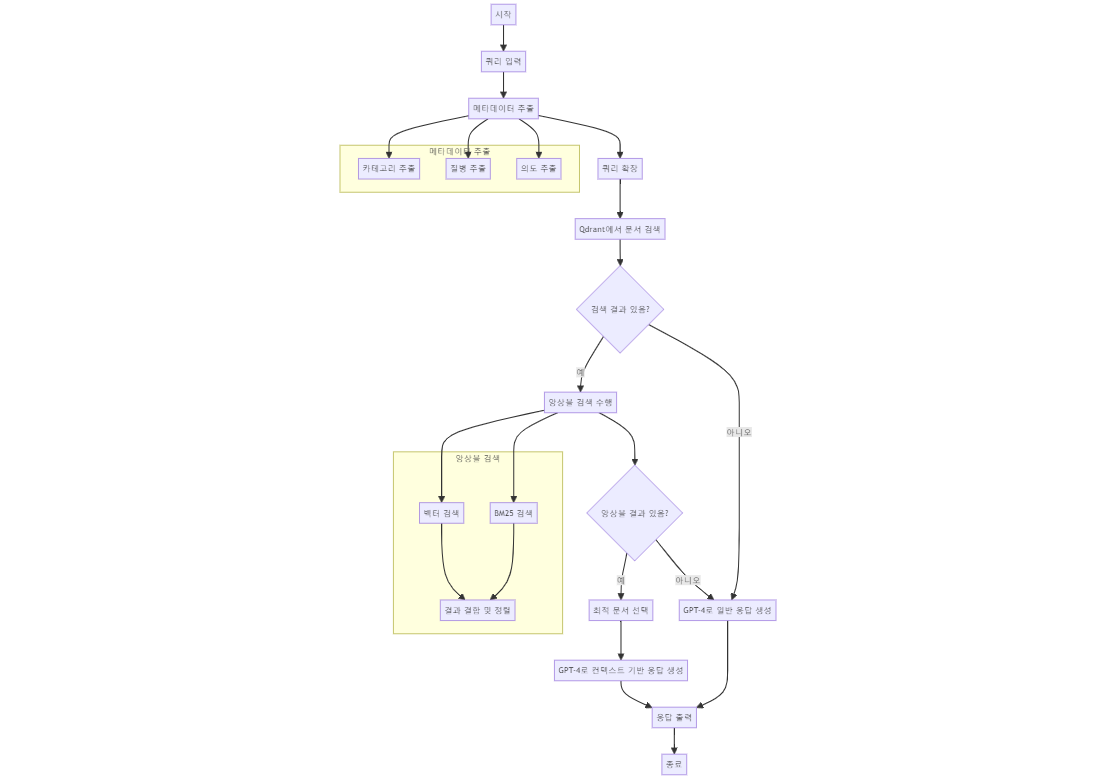

## 전체 코드

In [1]:
!pip install torch torchvision torchaudio
!pip install transformers
!pip install sentence-transformers
!pip install qdrant-client
!pip install langchain
!pip install langchain-community
!pip install langchain-openai
!pip install openai
!pip install scikit-learn
!pip install rank_bm25
!pip install tiktoken
!pip install numpy
!pip install tqdm
!pip install langchain-qdrant

In [2]:
import os
from typing import List, Dict, Any
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from langchain.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Qdrant as LangchainQdrant
from langchain.llms import OpenAI
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain_openai import OpenAI
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity
import logging
import time
import numpy as np
from openai import OpenAI as OpenAIClient
from google.colab import userdata

In [3]:
# OpenAI API 키 설정
openai_api_key = userdata.get('FINAL_TEAM3')

# Qdrant 클라이언트 초기화
QDRANT_URL = "https://6e46b2c2-f28a-4f28-854d-432ab699fdfd.europe-west3-0.gcp.cloud.qdrant.io"
QDRANT_API_KEY = "u2eejPgTwIyhr7BVjFBtkjGdGYPWvzQTBkoYycErtm5cyrFjwEEH9w"
COLLECTION_NAME = "son5"

client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

In [4]:
# 임베딩 모델 초기화
embeddings = HuggingFaceEmbeddings(model_name="jhgan/ko-sroberta-multitask")

# Langchain Qdrant 초기화
vector_store = LangchainQdrant(
    client=client,
    collection_name=COLLECTION_NAME,
    embeddings=embeddings
)

# Sentence Transformer 모델
st_model = SentenceTransformer('jhgan/ko-sroberta-multitask')

# OpenAI 클라이언트 초기화
openai_client = OpenAIClient(api_key=openai_api_key)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:141: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 0.3.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  warn_deprecated(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10

In [5]:
# 프롬프트 템플릿 정의
prompt_template = """
질문: {question}
관련 카테고리: {category}
관련 질병: {disease}
사용자 의도: {intent}
컨텍스트: {context}

위 정보를 바탕으로 답변해주세요:
"""

PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["question", "category", "disease", "intent", "context"]
)

In [6]:
print(f"API 키가 설정되었나요? {'예' if openai_api_key else '아니오'}")

API 키가 설정되었나요? 예


In [7]:
# OpenAI 클래스 초기화
llm = OpenAI(temperature=0.7, openai_api_key=openai_api_key)

# RetrievalQA 체인 생성
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_store.as_retriever(search_kwargs={"k": 5}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT}
)

In [8]:
def get_unique_metadata():
    try:
        response = client.scroll(
            collection_name=COLLECTION_NAME,
            scroll_filter=None,
            limit=10000,
            with_payload=True,
            with_vectors=False
        )

        categories = set()
        diseases = set()
        intents = set()

        for point in response[0]:
            category = point.payload.get("질병_카테고리")
            disease = point.payload.get("질병")
            intent = point.payload.get("의도")

            if category:
                categories.add(category)
            if disease:
                diseases.add(disease)
            if intent:
                intents.add(intent)

        return list(categories), list(diseases), list(intents)
    except Exception as e:
        logging.error(f"메타데이터 가져오기 중 오류 발생: {str(e)}")
        return [], [], []

DISEASE_CATEGORIES, DISEASES, INTENTS = get_unique_metadata()

In [9]:
def extract_metadata(query, categories, diseases, intents):
    query_lower = query.lower()
    category = next((cat for cat in categories if cat.lower() in query_lower), None)
    disease = next((dis for dis in diseases if dis.lower() in query_lower), None)
    intent = next((intent for intent in intents if intent.lower() in query_lower), None)
    logging.debug(f"추출된 메타데이터: 카테고리={category}, 질병={disease}, 의도={intent}")
    return category, disease, intent

In [10]:
def expand_query(query: str) -> List[str]:
    expanded_queries = [query]

    synonyms = {
        "증상": ["징후", "병증", "증세"],
        "치료": ["처치", "요법", "치료법"],
        "예방": ["방지", "예방책", "예방법"],
        "통증": ["아픔", "고통", "불편함"],
    } # 관련 데이터에서 빈도수 체크해서 사전 만들기

    words = query.split()
    for word in words:
        if word in synonyms:
            for syn in synonyms[word]:
                expanded_queries.append(query.replace(word, syn))

    category, disease, intent = extract_metadata(query, DISEASE_CATEGORIES, DISEASES, INTENTS)
    if category:
        expanded_queries.append(f"{query} {category}")
    if disease:
        expanded_queries.append(f"{query} {disease}")
    if intent:
        expanded_queries.append(f"{query} {intent}")

    logging.debug(f"확장된 쿼리: {expanded_queries}")
    return list(set(expanded_queries))

In [11]:
def bm25_search(query: str, documents: List[Any], top_k: int = 5) -> List[Any]:
    if not documents:
        logging.warning("BM25 검색: 문서 목록이 비어 있습니다.")
        return []
    try:
        corpus = [doc.page_content for doc in documents if hasattr(doc, 'page_content') and doc.page_content.strip()]
        if not corpus:
            logging.warning("BM25 검색: 모든 문서의 내용이 비어 있습니다.")
            return []
        bm25 = BM25Okapi(corpus)
        scores = bm25.get_scores(query.split())
        top_results = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)[:top_k]
        return [doc for doc, score in top_results]
    except Exception as e:
        logging.error(f"BM25 검색 중 오류 발생: {str(e)}")
        return []

In [12]:
def vector_search(query, documents, top_k=5):
    if not documents:
        logging.warning("벡터 검색: 문서 목록이 비어 있습니다.")
        return []
    query_embedding = st_model.encode([query])[0]
    doc_embeddings = st_model.encode([doc.page_content for doc in documents])
    similarities = cosine_similarity([query_embedding], doc_embeddings)[0]
    top_results = sorted(zip(documents, similarities), key=lambda x: x[1], reverse=True)[:top_k]
    return [doc for doc, score in top_results]

In [13]:
def ensemble_search(query: str, documents: List[Any], top_k: int = 5) -> List[Any]:
    if not documents:
        logging.warning("앙상블 검색: 문서 목록이 비어 있습니다.")
        return []
    bm25_results = bm25_search(query, documents, top_k)
    vector_results = vector_search(query, documents, top_k)

    combined_results = list(dict.fromkeys(bm25_results + vector_results))

    if not combined_results:
        logging.warning("앙상블 검색: 결과가 없습니다.")
        return []

    corpus = [doc.page_content for doc in combined_results if hasattr(doc, 'page_content')]
    if not corpus:
        logging.warning("앙상블 검색: 모든 문서의 내용이 비어 있습니다.")
        return []
    bm25 = BM25Okapi(corpus)
    scores = bm25.get_scores(query.split())
    sorted_results = sorted(zip(combined_results, scores), key=lambda x: x[1], reverse=True)

    return [doc for doc, _ in sorted_results[:top_k]]

In [14]:
def generate_gpt4_response(query: str, context: str = None, metadata: Dict[str, str] = None) -> str:
    try:
        system_message = "You are a helpful assistant specializing in medical information. Provide accurate and concise answers based on the given context and metadata."
        user_message = f"Question: {query}\n\nContext: {context}\n\nMetadata: {metadata}"

        response = openai_client.chat.completions.create(
            model="gpt-4-turbo-preview",
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_message}
            ],
            max_tokens=150,
            n=1,
            stop=None,
            temperature=0.7,
        )

        return response.choices[0].message.content.strip()
    except Exception as e:
        logging.error(f"GPT-4 응답 생성 중 오류 발생: {str(e)}")
        return f"죄송합니다. GPT-4 응답을 생성하는 중에 오류가 발생했습니다: {str(e)}"

In [15]:
def process_query(query: str) -> str:
    start_time = time.time()

    logging.info(f"처리 중인 쿼리: {query}")
    category, disease, intent = extract_metadata(query, DISEASE_CATEGORIES, DISEASES, INTENTS)
    logging.info(f"추출된 메타데이터: 카테고리={category}, 질병={disease}, 의도={intent}")

    expanded_queries = expand_query(query)
    logging.info(f"확장된 쿼리: {expanded_queries}")

    try:
        all_documents = vector_store.similarity_search(query, k=20)

        if not all_documents:
            logging.warning("Qdrant에서 검색 결과가 없습니다.")
            return generate_gpt4_response(query)

        ensemble_results = ensemble_search(query, all_documents, top_k=5)

        if not ensemble_results:
            logging.warning("앙상블 검색 결과가 없습니다.")
            return generate_gpt4_response(query)

        best_match = ensemble_results[0]
        context = best_match.page_content if hasattr(best_match, 'page_content') else ""
        metadata = best_match.metadata if hasattr(best_match, 'metadata') else {}

        end_time = time.time()
        processing_time = end_time - start_time
        logging.info(f"처리 시간: {processing_time:.2f}초")

        return generate_gpt4_response(query, context=context, metadata=metadata)
    except Exception as e:
        logging.error(f"쿼리 처리 중 오류 발생: {str(e)}")
        return generate_gpt4_response(query)


In [16]:
def evaluate_system():
    test_queries = [
        "감기에 걸렸을 때 어떻게 해야 하나요?",
        "고혈압의 증상은 무엇인가요?",
        "당뇨병 예방을 위한 식습관은?",
        "코로나19 백신의 부작용은 무엇인가요?",
        "불면증 해소 방법에는 무엇이 있나요?"
    ]

    total_time = 0
    for query in test_queries:
        start_time = time.time()
        response = process_query(query)
        end_time = time.time()

        processing_time = end_time - start_time
        total_time += processing_time

        print(f"질문: {query}")
        print(f"답변: {response}")
        print(f"처리 시간: {processing_time:.2f}초")
        print("-" * 50)

    avg_time = total_time / len(test_queries)
    print(f"평균 처리 시간: {avg_time:.2f}초")

if __name__ == "__main__":
    evaluate_system()

ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)


질문: 감기에 걸렸을 때 어떻게 해야 하나요?
답변: 감기에 걸렸을 때는 다음과 같은 방법으로 대처할 수 있습니다:

1. 충분한 휴식: 몸이 회복할 수 있도록 충분한 휴식을 취하세요.
2. 수분 섭취: 물이나 따뜻한 차와 같은 수분을 충분히 섭취하여 탈수를 방지하세요.
3. 온화한 음식 섭취: 목이 아플 경우, 부드럽고 온화한 음식을 섭취하는
처리 시간: 5.29초
--------------------------------------------------


ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)


질문: 고혈압의 증상은 무엇인가요?
답변: 고혈압은 대부분 초기에는 증상이 없는 경우가 많지만, 혈압이 매우 높아지면 다음과 같은 증상이 나타날 수 있습니다:

- 두통
- 숨가쁨
- 코피
- 어지럼증
- 가슴 통증
- 시야 문제
- 심한 경우, 심장 발작이나 뇌졸중으로 이어질 수 있음

고혈압은 "조용한 살인자"
처리 시간: 4.12초
--------------------------------------------------


ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)


질문: 당뇨병 예방을 위한 식습관은?
답변: 당뇨병 예방을 위한 식습관은 다음과 같습니다:

1. **고섬유질 식품 섭취**: 과일, 채소, 통곡물 등 고섬유질 식품을 많이 섭취하면 혈당 조절에 도움이 됩니다.

2. **설탕과 가공식품 줄이기**: 설탕이 많이 들어있거나 가공된 식품은 혈당을 급격
처리 시간: 4.23초
--------------------------------------------------


ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)


질문: 코로나19 백신의 부작용은 무엇인가요?
답변: 코로나19 백신의 부작용은 대부분 경미하며 일시적인 것으로 알려져 있습니다. 가장 흔한 부작용으로는 접종 부위의 통증, 피로감, 두통, 근육통, 오한, 발열, 관절통 등이 있습니다. 이러한 증상은 보통 접종 후 며칠 이내에 사라집니다.

드물게, 코로나19 백신은 보다 심각한 부작용
처리 시간: 4.01초
--------------------------------------------------


ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)


질문: 불면증 해소 방법에는 무엇이 있나요?
답변: 불면증을 해소하는 방법은 여러 가지가 있습니다. 개인의 상황과 불면증의 원인에 따라 다음과 같은 방법들이 도움이 될 수 있습니다:

1. **수면 위생 개선**: 규칙적인 수면 스케줄을 유지하고, 침실을 편안하고 조용하며 어둡게 유지합니다. 침대는 오직 수면과 성관계를 위한 곳으로 사용하는 것이
처리 시간: 4.25초
--------------------------------------------------
평균 처리 시간: 4.38초


결과 해석 :
 - 답변 자체는 빠르게 잘 나오는 것을 보임(평균 : 4.38초)
 - 단, 토큰 제한에 의해 답변이 짤리는 것을 확인함
 - 이 문제를 해결하면 서비스로 사용가능한 것으로 사료됨.

오류 :

ERROR:root:쿼리 처리 중 오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)

이유 :
 - Document 객체의 page_content 필드가 None 값을 가지고 있기 때문에 발생
 - Qdrant에서 검색된 문서의 내용이 비어있거나, 검색 과정에서 문제가 발생했을 가능성을 시사


해결 방법 :
 - 검색 결과 필터링:
ensemble_search 함수에서 None 값을 가진 문서를 필터링하는 로직을 추가
 - 예외 처리 추가:
process_query 함수에서 예외 처리를 추가하여 None 값을 가진 문서를 처리
 - Qdrant 검색 결과 확인:
Qdrant에서 실제로 문서를 검색할 수 있는지 확인합니다. 다음과 같은 코드를 추가하여 검색 결과를 로깅
 - Qdrant 컬렉션 확인:
Qdrant 컬렉션에 실제로 데이터가 있는지 확인합니다. 다음 코드를 실행하여 컬렉션 정보를 확인